In [ ]:
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp '/content/drive/My Drive/kaggle.json' ~/.kaggle/
# !kaggle datasets download -d tinashri/brain-tumor-segmentation-datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!zip -r '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test.zip' '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test'

In [ ]:
# !unzip '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets.zip' -d '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets'

In [ ]:
from fastai.vision.all import *
import os
import numpy as np
import tqdm as notebook_tqdm

**Convert Images**

In [ ]:
import cv2 as cv
import os

if __name__ == '__main__':
    lbl_dir = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Label'
    fixed_lbl_dir = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Fixed_Label'
    lbl_list = os.listdir(lbl_dir)

    # for img_name in lbl_list:
    #     lbl = cv.imread(os.path.join(lbl_dir, img_name))
    #     lbl = lbl/255
    #     # lbl = cv.resize(lbl, (150, 120))
    #     lbl_path = os.path.join(fixed_lbl_dir, img_name)
    #     cv.imwrite(lbl_path, lbl)
    #     # print(lbl_path)

**Preparing Data**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Fixed_Label'
    return os.path.join(path, f"{fn.stem}.png")

path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Flip(),Brightness(0.1,p=0.25),Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files,
               get_y=label_func)
dls = db.dataloaders(os.path.join(path, 'Image'), path=path,bs = 8)
# dls.show_batch(max_n=3)

/usr/local/lib/python3.7/dist-packages/torch/_tensor.py:1121: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  ret = func(*args, **kwargs)


In [ ]:
print('Number of training Images:',len(dls.train_ds))
print('Number of validation Images:',len(dls.valid_ds))

Number of training Images: 2372
Number of validation Images: 592


/usr/local/lib/python3.7/dist-packages/torch/_tensor.py:1121: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  ret = func(*args, **kwargs)


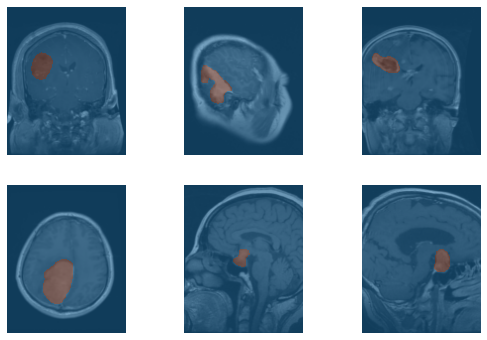

In [ ]:
dls.show_batch(max_n=6)

In [ ]:
learn = unet_learner(dls, resnet50, metrics=[Dice],cbs=[SaveModelCallback(),
                                                        ShowGraphCallback()])
# learn.lr_find()


In [ ]:
learn.fit_one_cycle(1)

**Load Model**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test/Label'
    return os.path.join(path, f"{fn.stem}.png")

model_path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/models/Model_train_loss_0_009_valid_loss_0_021_dice_0_8243_e12_E20_Resnet50'

path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files,
               get_y=label_func)
dls = db.dataloaders(os.path.join(path, 'Image'), path=path,bs = 8)
# dls.show_batch(max_n=3)

learn = unet_learner(dls, resnet50, metrics=[Dice])
learn = learn.load(model_path)
learn.summary()

In [ ]:
learn.show_results(ds_idx=10, dl=dls, max_n=3, figsize=(50,50))

In [ ]:
 preds, targs = learn.get_preds(dl=dls)

**Test with CTScan Images**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test/Label'
    return os.path.join(path, f"{fn.stem}.png")

model_path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/models/Model_train_loss_0_009_valid_loss_0_021_dice_0_8243_e12_E20_Resnet50'

path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files)
dls = db.dataloaders(os.path.join(path, 'CTBrainTumorImages/CT Brain Tumor Images'), path=path,bs = 4)
# dls.show_batch(max_n=3)

learn = unet_learner(dls, resnet50, metrics=[Dice])
learn = learn.load(model_path)
learn.summary()

/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

/usr/local/lib/python3.8/dist-packages/fastai/learner.py:58: UserWarning: Saved filed doesn't contain an optimizer state.
  elif with_opt: warn("Saved filed doesn't contain an optimizer state.")


DynamicUnet (Input shape: 4 x 3 x 150 x 120)
Layer (type)         Output Shape         Param #    Trainable 
                     4 x 64 x 75 x 60    
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     4 x 64 x 38 x 30    
MaxPool2d                                                      
Conv2d                                    4096       False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
____________________________________________________________________________
                     4 x 256 x 38 x 30   
Conv2d                                    16384      False     
BatchNorm2d                        

In [ ]:
from PIL import Image
import numpy as np
test_path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/' \
            'data/Test/CTBrainTumorImages/CT Brain Tumor Images/Cancer (1598).jpg'
img = np.array(Image.open(test_path).resize((120,150)))
cat, tensor, probs = learn.predict(img)


In [ ]:
print(img.shape)
print(img.ndim)

print(np.array(cat).shape)
print(np.array(cat).ndim)

(150, 120, 3)
3
(150, 120)
2


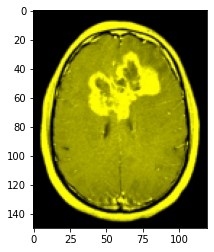

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img2 = np.stack([img, np.array(cat)])
plt.imshow(img2)
plt.show()


In [ ]:
dls.cat

In [ ]:
 preds, targs = learn.get_preds(dl=dls)